:::{admonition} Run this notebook yourself!
:class: important

Download the executed notebook: **{nb-download}`ds_index.ipynb`**!

Run it in your browser: **{binder}`ds_index.ipynb`**!

:::

(datasaurus-index)=
# Using Penalized Metamer Synthesis to Recreate the Datasaurus Dozen

:::{admonition} Penalty function usage
:class: warning

These pages assume familiarity with the basics of using penalty function in metamer synthesis, as shown in the [](how-to-penalty) notebook.

:::

The [Datasaurus dozen](https://en.wikipedia.org/wiki/Datasaurus_dozen) consists of thirteen datasets with very different visual appearances but nearly-identical simple descriptive statistics. It was created by {cite:alp}`Matejka2017-same-stats` to highlight the importance of visualizing your data and was inspired by the earlier [Anscombe's Quartet](https://en.wikipedia.org/wiki/Anscombe's_quartet).

These datasets all consist of 142 `(x, y)` points, and all have the same mean and standard deviation (for both x and y), correlation between x and y, linear regression line, and coefficient of determination for that linear regression. Put another way, despite consisting of a different set of values, these datasets all have the same set of summary statistics -- that is, they are model metamers!

In this notebook, we will visualize the original datasaurus dozen, implement a model to compute the relevant statistics, and demonstrate that they are metamers for that model. We will then visualize a new set of metamers, synthesized using plenoptic's {class}`~plenoptic.Metamer` using the {attr}`~plenoptic.Metamer.penalty_function` argument to steer synthesis towards visually-interesting results. The other notebooks in this series demonstrate how to synthesize each of those metamers individually.

In [1]:
import itertools

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import torch

import plenoptic as po

# use one of our helper functions for making videos.
from plenoptic.plot.display import _update_stem

# so that relative sizes of axes created by po.plot.imshow and others look right
plt.rcParams["figure.dpi"] = 72

plt.rcParams["animation.html"] = "html5"
# use single-threaded ffmpeg for animation writer
plt.rcParams["animation.writer"] = "ffmpeg"
plt.rcParams["animation.ffmpeg_args"] = ["-threads", "1"]
plt.rcParams["savefig.bbox"] = "tight"

We have downloaded the original datasaurus dozen from [OpenIntro](https://www.openintro.org/data/index.php?data=datasaurus) and reformatted it as a torch tensor of shape `(13, 2, 142)`, with an accompanying numpy array specifying the names of each dataset. These can be downloaded using {func}`plenoptic.data.fetch_data` and then loaded in using numpy and torch:

In [2]:
datasaurus_tarball = po.data.fetch_data("datasaurus.tar.gz")
data = torch.load(datasaurus_tarball / "datasaurus.pt")
categories = np.load(datasaurus_tarball / "categories.npy", allow_pickle=True)

The following cell defines helper functions to visualize and animate the datasets and their representation. The specifics are not important for our purposes, but if you're interested, you can expand the following cell to see their implementations:

In [3]:
def plot_datasaurus(data, categories, ax_size=2, scatter_kwargs=None, fig=None):
    if scatter_kwargs is None:
        scatter_kwargs = {}
    scatter_kwargs.setdefault("s", 5)
    n_rows = min(3, len(data) - 1)
    n_cols = int(max(np.ceil((len(data) - 1) / n_rows + 1), 2))
    if fig is None:
        fig = plt.figure(
            figsize=(ax_size * n_cols, ax_size * n_rows), layout="compressed"
        )
    axes = fig.subplots(n_rows, n_cols, sharex=True, sharey=True, squeeze=False)
    if n_rows == 1:
        dino_ax = axes[0, 0]
    if n_rows > 1:
        dino_ax = axes[1, 0]
        axes[0, 0].set_visible(False)
    if n_rows > 2:
        axes[2, 0].set_visible(False)
    axes = [dino_ax] + [ax for ax in axes[:, 1:].T.flatten()]
    for xy, title, ax in zip(data, categories, axes):
        ax.scatter(*xy, **scatter_kwargs)
        ax.set_title(title)
        ax.set_aspect(1)
    ax.set(xlim=(0, 100), ylim=(0, 100))
    for ax in axes[len(data) :]:
        ax.set_visible(False)
    return fig, axes


def update_datasaurus(data, axes):
    artists = []
    for d, ax in zip(data, axes):
        art = ax.collections[0]
        art.set_offsets(d.T)
        artists.append(art)
    return artists


def plot_datasaurus_rep(data, categories, model, ax_size=2, aspect=1.3, fig=None):
    n_rows = min(3, len(data) - 1)
    n_cols = int(max(np.ceil((len(data) - 1) / n_rows + 1), 2))
    if fig is None:
        fig = plt.figure(
            figsize=(ax_size * n_cols * aspect, ax_size * n_rows), layout="compressed"
        )
    gs = fig.add_gridspec(n_rows, n_cols, wspace=0.25)
    return_axes = []
    turn_off_axes = []
    if n_rows > 1:
        turn_off_axes.append(0)
    if n_rows > 2:
        turn_off_axes.append(2)
    data_idx = 0
    ylims = [[0, 0], [0, 0]]
    for j, i in itertools.product(range(n_cols), range(n_rows)):
        if j == 0 and i in turn_off_axes:
            continue
        else:
            try:
                y = data[data_idx]
                title = categories[data_idx]
            except IndexError:
                continue
            sgs = gs[i, j].subgridspec(1, 2, width_ratios=[5, 3], wspace=0.15)
            plot_axes = [fig.add_subplot(sgs[i]) for i in range(2)]
            plot_axes[0].set_title(title, x=1)
            plot_axes = model.plot_representation(y, plot_axes)
            model.plot_representation(data[0], plot_axes, "lines")
            for i, (ax, ylim) in enumerate(zip(plot_axes, ylims)):
                ax_ylim = ax.get_ylim()
                ylims[i] = [min(ax_ylim[0], ylim[0]), max(ax_ylim[1], ylim[1])]
            if j == 0:
                try:
                    fig.set_layout_engine("none")
                except AttributeError:
                    # then this is a subfigure
                    fig.figure.set_layout_engine("none")
            else:
                for ax in plot_axes:
                    ax.set(yticklabels=[], xticklabels=[])
        data_idx += 1
        return_axes.append(plot_axes)
    # small adjustment so that dino plots don't overlap with yticklabels
    ax = return_axes[0][0]
    pos = [p for p in ax.get_position().bounds]
    pos[0] -= return_axes[0][1].get_position().bounds[2] / 1.2
    ax.set_position(pos)
    for axes in return_axes:
        for ax, ylim in zip(axes, ylims):
            ax.set_ylim(ylim)
    return fig, return_axes


def update_datasaurus_rep(data, axes, model):
    artists = []
    for d, axs in zip(data, axes):
        artists.append(_update_stem(axs[0].containers[0], d[:5]))
        artists.append(_update_stem(axs[1].containers[0], d[5:]))
    return artists

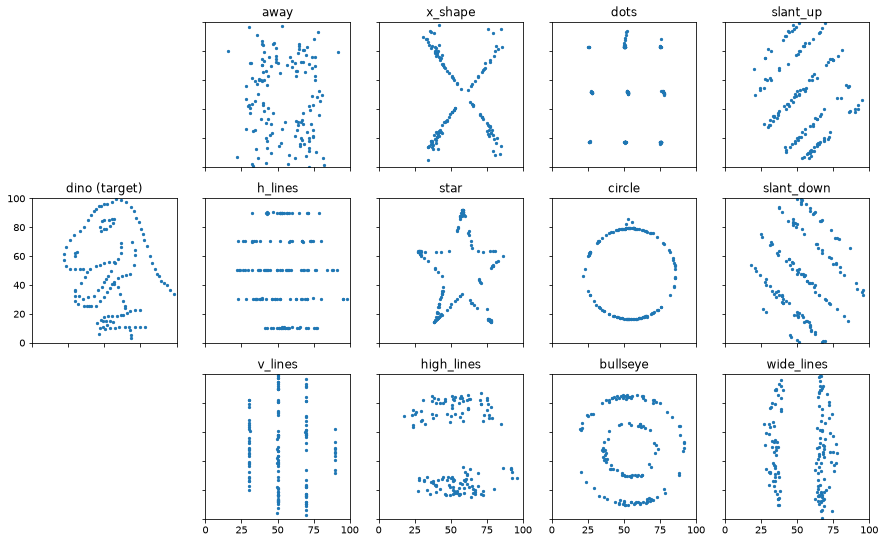

In [4]:
ax_size = 3
n_cols, n_rows = (5, 3)
data_fig = plt.figure(figsize=(ax_size * n_cols, ax_size * n_rows))
plot_datasaurus(data, categories, fig=data_fig);

In the above figure, the leftmost subplot shows the original dino dataset. The other twelve subplots show each of the twelve metameric datasets from {cite:alp}`Matejka2017-same-stats`, as can also be seen in [the wikipedia article](https://en.wikipedia.org/wiki/Datasaurus_dozen).

The following cell defines the model that computes the summary statistics for us to match: the mean and standard deviation of both dimensions, the correlation between them, the slope and intercept from linear regression, and the corresponding coefficient of determination. We also define a `plot_representation` <!-- skip-lint --> function to visualize these eight numbers, as we'll see below. This cell is hidden because the plotting functionality is complicated, feel free to expand if you'd like to see how it's implemented.

In [5]:
class DatasaurusModel(torch.nn.Module):
    def __init__(self, n_pts=None, dtype=None):
        """
        Create model to measure datasaurus stats.

        Parameters
        ----------
        n_pts
            Number of data points in the dataset we'll use the model for. Used to cache
            a corresponding vector of ones for computing linear regression.
        dtype
            dtype for the dataset we'll use the model for. Used to cache
            a corresponding vector of ones for computing linear regression.
        """
        super().__init__()
        # cache ones to save time
        if n_pts is not None:
            self._ones = torch.ones(n_pts, dtype=dtype)
        else:
            self._ones = None
        # This model has no trainable parameters, so it's always in eval mode
        self.eval()

    def _prepare_X(self, x):
        """Append vector of ones to matrix for linear regression (for intercept)."""
        ones = self._ones if self._ones is None else torch.ones_like(x)
        return torch.stack([ones, x], -1)

    def _compute_linreg(self, x, y):
        """Compute linear regression (with intercept) between x and y."""
        X = self._prepare_X(x)
        # unsqueezing and squeezing needed because of https://github.com/pytorch/pytorch/issues/158169
        return torch.linalg.lstsq(X, y.unsqueeze(-1)).solution.squeeze()

    def _compute_coeff_determination(self, x, y, solution):
        """Compute R^2 for linera regression fit."""
        X = self._prepare_X(x)
        pred_y = torch.einsum("x, n x -> n", solution, X)
        ss_res = (y - pred_y).pow(2).sum()
        ss_tot = (y - y.mean()).pow(2).sum()
        return 1 - (ss_res / ss_tot)

    def _vmap_coeff_determination(self, x, solution):
        """vmap _compute_coeff_determiniation across dim=0."""
        f = torch.func.vmap(lambda x, solt: self._compute_coeff_determination(*x, solt))
        return f(x, solution).unsqueeze(-1)

    def forward(self, data):
        """Compute summary statistics on data."""
        if data.ndim == 2:
            data = data.unsqueeze(0)
        elif data.ndim != 3:
            raise ValueError("data must be 2 or 3d!")
        stats = []
        stats.append(data.mean(-1))
        stats.append(data.std(-1))
        solution = torch.func.vmap(lambda x: self._compute_linreg(*x))(data)
        stats.append(solution)
        crosscorr = torch.func.vmap(lambda x: torch.corrcoef(x)[0, 1])(data)
        stats.append(crosscorr.unsqueeze(-1))
        stats.append(self._vmap_coeff_determination(data, solution))
        return torch.cat(stats, -1)

    def plot_representation(self, data, ax=None, style="stem", figsize=(6, 3)):
        """
        Plot model representation of data.

        We plot the representation as stem plots (if style=="stem") or dashed
        horizontal lines (if style=="lines"), on two separate sub-axes. The grouping
        is determined by their approximate magnitude in the original dino dataset. The
        first contains ["x mean", "y mean", "x std", "y std", "linreg intercept"], while
        the second contains ["linreg slope", "correlation", and "R^2"].

        Parameters
        ----------
        data: torch.Tensor
            The data to show on the plot. Should look like the output of
            forward, with the exact same structure.
        ax: plt.Axes or None
            Axes where we will plot the data. If a plt.Axes instance, will
            subdivide into 2 new axes. If None, we create a new figure.
        style: {"stem", "lines"}
            If "stem", plot data as stem plot. If "lines", plot as dashed
            horizontal lines.
        figsize: tuple[int]
            The size of the figure to create. Ignored if ax is not None.

        Returns
        -------
        axes
            List of two axes containing the subplots.
        """
        data = po.to_numpy(data).squeeze()
        # Set up grid spec
        if ax is None:
            # we add 2 to order because we're adding one to get the
            # number of orientations and then another one to add an
            # extra column for the mean luminance plot
            fig = plt.figure(figsize=figsize, layout="constrained")
            gs = mpl.gridspec.GridSpec(1, 2, fig, width_ratios=[5, 3])
            axes = [fig.add_subplot(gs[0, i]) for i in range(2)]
        elif isinstance(ax, mpl.axes.Axes) or len(ax) == 1:
            # want to make sure the axis we're taking over is basically invisible.
            ax = po.plot.display._clean_up_axes(
                ax, False, ["top", "right", "bottom", "left"], ["x", "y"]
            )
            gs = ax.get_subplotspec().subgridspec(1, 2, width_ratios=[5, 3])
            fig = ax.figure
            axes = [fig.add_subplot(gs[0, i]) for i in range(2)]
        else:
            axes = ax
            fig = axes[0].figure

        labels = [
            "x mean",
            "y mean",
            "x std",
            "y std",
            "linreg intercept",
            "linreg slope",
            "correlation",
            "$R^2$",
        ]
        cutoff = 5
        linewidth = 1
        for i, ax in enumerate(axes):
            if i == 0:
                slicer = slice(0, cutoff)
            elif i == 1:
                slicer = slice(cutoff, len(labels) + 1)
            y = data[slicer]
            labs = labels[slicer]
            x = np.arange(len(labs))

            if style == "stem":
                ax.stem(y)
            elif style == "lines":
                ax.hlines(y, x - linewidth / 2, x + linewidth / 2, "k", "--")
            ax.set_xticks(x, labs, rotation=30, ha="right")
        return axes

:::{admonition} Redundant statistics?
:class: dropdown note

Our `DatasaurusModel` contains redundant statistics: the slope and intercept of the best-fit line and the corresponding coefficient of determination provide no additional constraints over the other five statistics. Put another way, it is impossible to generate a dataset that has matched means, variances, and correlation of x and y without also matching the remaining three statistics. (The demonstration of this fact is left as an exercise to the reader.)

However, in practice, we find that adding those redundant statistics makes the optimization easier: it converges faster and results in a solution that better balances the metamer loss and penalty.

If you would like to see for yourself, try removing the corresponding computations from the `forward` <!-- skip-lint --> method of `DatasaurusModel` and running synthesis yourself:
the reduced model finds good solutions for the simpler penalties such as [](ds_circle.md) and [](ds_away.md), and has difficulty for the more complex ones such as [](ds_slantup.md) and [](ds_vwidelines.md). Note that if you wish to create the plots and movies shown in these notebooks, so that you can see for yourself that the redundant statistics are also matched, you should use the existing `DatasaurusModel` to do so. See [](ps-mag-means) for a similar example and discussion for the {class}`~plenoptic.models.PortillaSimoncelli` model.

:::

Let's use our model and one of our plotting helper functions to visualize the model output on the datasaurus dozen:

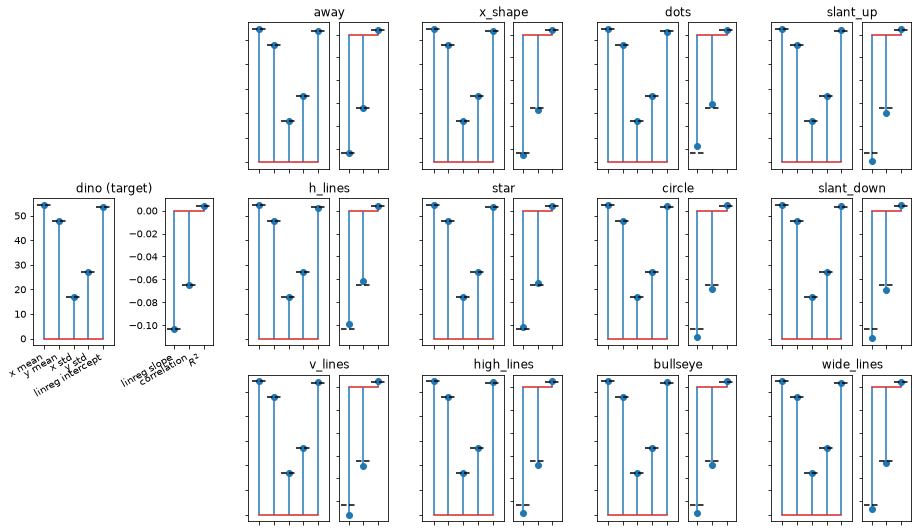

In [6]:
# expand folded cell above to see definition of this model
model = DatasaurusModel(data.shape[1], data.dtype)
rep_fig = plt.figure(figsize=(ax_size * n_cols, ax_size * n_rows))
plot_datasaurus_rep(model(data), categories, model, fig=rep_fig);

The plot layout is the same as the first plot: the subplot on the far left corresponds to the dino dataset, and the others correspond to the metameric datasets. For each dataset, we're plotting the model output as two stem plots, based on their approximate magnitude: the means, standard deviations, and intercept of the linear regression in the first, and the slope of the linear regression, correlation, and coefficient of determination ($R^2$) of the linear regression in the second. Each subplot also shows the values for the dino dataset as dashed horizontal lines.

You can see that all the datasets approximately match on all statistics, with some error around the slope of the linear regression and the correlation for some of the datasets (if we double-check [the wikipedia page](https://en.wikipedia.org/wiki/Datasaurus_dozen), we can see that the accuracy is different for different statistics). That shows us that these dataset are all metamers for our `DatasaurusModel`.

The authors of {cite:alp}`Matejka2017-same-stats` generated the datasets shown above using a [simulated annealing](https://en.wikipedia.org/wiki/Simulated_annealing) procedure: starting from the dino dataset, they made small random perturbations to the points, with the goal of matching a target shape as defined by a line drawing. A perturbation was accepted if it either made the dataset more like the target shape or if some gradually decreasing temperature was above some random number. After a perturbed dataset was accepted, it was checked for statistical equivalence (up to the specified number of decimal places) against the initial dataset and, if not, another random perturbation was tried.

This is a very different procedure than plenoptic's metamer synthesis! Importantly, the original procedure starts from the dino dataset and tries to change its appearance towards some target while preserving the intended statistics, while plenoptic's starts form any set of 142 `(x, y)` points and changes it so that its statistics match that of the dino dataset.

There is one additional wrinkle: as the authors point out, it's fairly straightforward to generate random datasets whose statistics match --- the difficulty lies in finding datasets that are "clearly different and identifiably distinct" while having the same statistical properties.

Using plenoptic, we can generate metameric datasets in a relatively straightforward manner, though note that even in this simple case, we have to tweak the penalty. As plenoptic was largely developed to work on images, the default {attr}`~plenoptic.Metamer.penalty_function` is {func}`~plenoptic.regularize.penalize_range` which, with its default values, encourages values to lie between 0 and 1. For this synthesis problem, we instead want the values to lie between 0 and 100, so we write a custom `penalty` which calls {func}`~plenoptic.regularize.penalize_range` while specifying an allowed range of `(0, 100)`.

In [7]:
# default penalty penalizes points whose values lie outside the (0, 1) range,
# so we need to specify we allow (0, 100) instead
def penalty(x):
    return po.regularize.penalize_range(x, (0, 100))


# data[0] is the dinosaur
met = po.Metamer(data[0], model, penalty_function=penalty)
# By default, we initialize metamer synthesis with points between 0 and 1
met.setup(initial_image=100 * torch.rand_like(data[0]), optimizer=torch.optim.LBFGS)
met.synthesize(20, store_progress=True)

/home/jenkins/agent/workspace/CCN_neurorse_plenoptic_PR-492/lib/python3.12/site-packages/plenoptic/validate.py:101: UserWarning: plenoptic's methods have mostly been tested on 4d inputs with shape torch.Size([n_batch, n_channels, im_height, im_width]). They should theoretically work with different dimensionality; if you have any problems, please open an issue at https://github.com/plenoptic-org/plenoptic/issues/new?template=bug_report.md
  warnings.warn(
/home/jenkins/agent/workspace/CCN_neurorse_plenoptic_PR-492/lib/python3.12/site-packages/plenoptic/validate.py:116: UserWarning: input_tensor range is (2.9487, 99.4872); plenoptic's methods have largely been tested with the range [0, 1]. Synthesis should still work, but if you have any problems, please open an issue.
  warnings.warn(
/home/jenkins/agent/workspace/CCN_neurorse_plenoptic_PR-492/lib/python3.12/site-packages/plenoptic/validate.py:116: UserWarning: input_tensor range is (0.1257862439961177, 99.9693332455171); plenoptic's me

  0%|          | 0/20 [00:00<?, ?it/s]

In [8]:
# Initialize figure by plotting the first iteration
fig, axes = plt.subplots(
    1, 3, figsize=(8, 3), width_ratios=[5, 5, 3], layout="compressed"
)
plot_data = met.saved_metamer
ani_data = po.to_numpy(plot_data)
ani_rep = po.to_numpy(model(plot_data))
path = axes[0].scatter(*ani_data[0])
axes[0].set(xlim=(0, 100), ylim=(0, 100))
axes[0].set_aspect(1)

rep_axes = model.plot_representation(model(data)[0], axes[1:], "lines")
model.plot_representation(ani_rep[0], rep_axes)
fig.set_layout_engine("none")


# Update the data for each saved iteration.
def animate(i):
    path.set_offsets(ani_data[i].T)
    _update_stem(rep_axes[0].containers[0], ani_rep[i, :5])
    _update_stem(rep_axes[1].containers[0], ani_rep[i, 5:])


ani = mpl.animation.FuncAnimation(fig, animate, range(len(plot_data)), repeat=False)
plt.close(fig)
ani

In the video above, the leftmost plot shows the metameric dataset over synthesis, while the right-two show the model's representation at each stage (the horizontal lines show the representation of the dino, which is our target).

We can see that our synthesis procedure fairly quickly finds a metamer, starting from uniformly-distributed dots with x and y values between 0 and 100. However, the metamer doesn't look all that interesting: it still looks like a fairly random smattering of dots.

In order to find "clearly different and identifiably distinct" datasets, we need to do something more. Specifically, we can use {attr}`~plenoptic.Metamer.penalty_function` to bias the synthesis procedure. In this case, we can create penalty functions that encourage the dataset to have specific shapes. By passing them to {class}`~plenoptic.Metamer` at initialization, we can try to find datasets that are both `DatasaurusModel` metamers and "identifiably distinct".

The other notebooks in this section demonstrate how to do this, for a wide variety of shapes. First, let's see what they look like. The following hidden cell loads in the cached metamers and creates figures showing the datasets and their representations, laid out like the above ones:

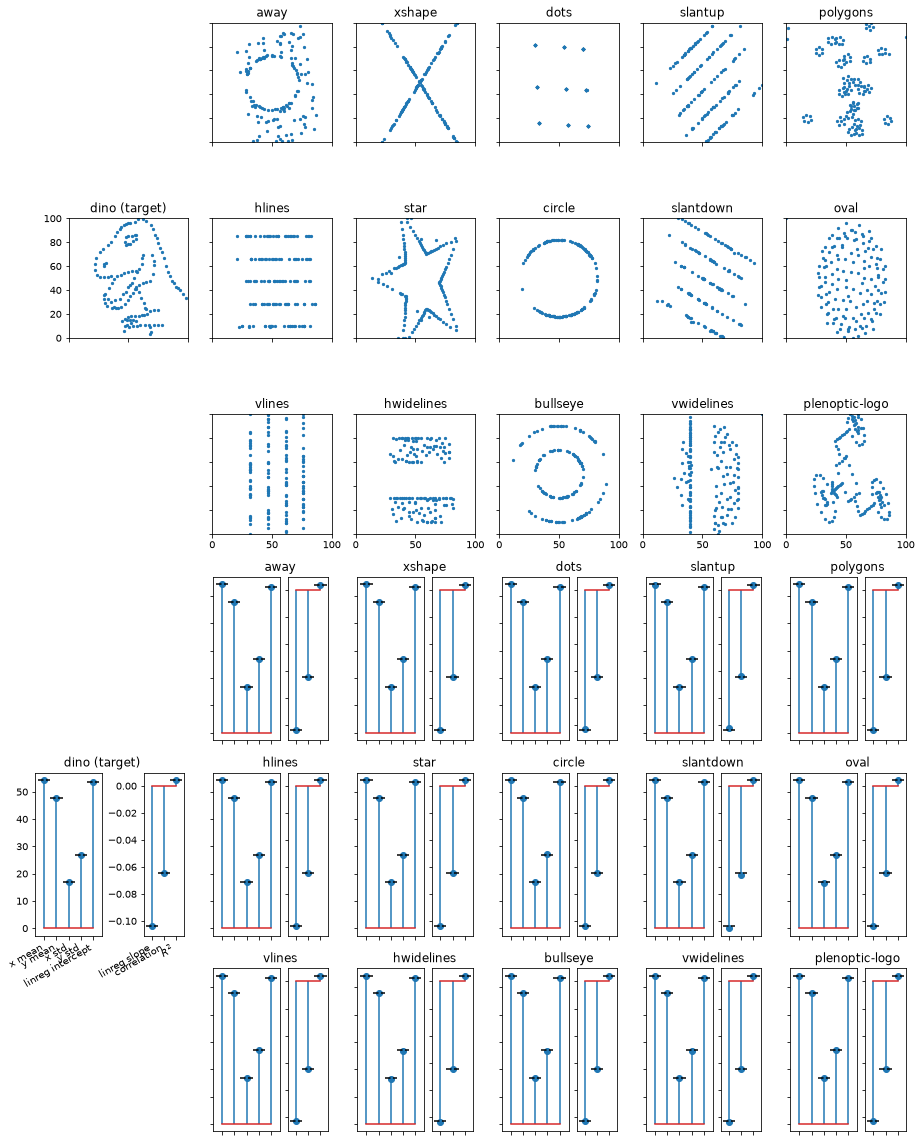

In [9]:
# for creating the plot
cached_metamers = []
# for animating the video
saved_metamers = []
# match order of initial data, plus our extras
titles = [
    "away",
    "hlines",
    "vlines",
    "xshape",
    "star",
    "hwidelines",
    "dots",
    "circle",
    "bullseye",
    "slantup",
    "slantdown",
    "vwidelines",
    "polygons",
    "oval",
    "plenoptic-logo",
]
metamer_tarball = po.data.fetch_data("datasaurus_metamers.tar.gz")
for t in titles:
    # synthesis for star is more complex and so it's saved slightly differently. see
    # its notebook for more details.
    f = metamer_tarball / f"datasaurus-{t}.pt"
    cached_metamers.append(torch.load(f)["_metamer"])
    if t == "star":
        f = metamer_tarball / f"datasaurus-{t}-saved.pt"
        saved_metamers.append(torch.load(f).detach())
    else:
        saved_metamers.append(torch.stack(torch.load(f)["_saved_metamer"]).detach())
cached_metamers = torch.stack([data[0], *cached_metamers])
titles = ["dino (target)"] + titles
saved_metamers = torch.stack(saved_metamers)

ax_size = 3
n_cols, n_rows = (5, 3)
fig = plt.figure(figsize=(ax_size * n_cols, ax_size * n_rows * 2))
subfigs = fig.subfigures(2, 1, hspace=-0.2)
plot_datasaurus(cached_metamers, titles, fig=subfigs[0])
plot_datasaurus_rep(model(cached_metamers), titles, model, fig=subfigs[1]);

As in the above plots, the leftmost subplot corresponds to our target, the dino dataset. Each of the remaining ones shows a distinct metameric dataset, with the top figure showing the datasets themselves, and the bottom showing their representation (with the dino's representation shown as dashed horizontal lines on each plot). Several things to note:

- The plots are laid out in the same order as above, with the addition of three extra datasets (in the rightmost column).
- The majority of these datasets start from randomly-distributed points between with x and y values between 0 and 1 and use {class}`torch.optim.LBFGS` to find a `DatasaurusModel` metamer for the dino dataset in 50 iterations with some custom penalty functions. The exceptions are:
    - [](ds_plenoptic_logo.md), which starts from a points arranged into the plenoptic logo and uses no penalty function. The procedure outlined in {cite:alp}`Matejka2017-same-stats` does not allow for arbitrary initialization, and we wished to present an example that does so.
    - [](ds_star.md) requires a more complex, two-stage synthesis procedure: first a star is synthesized with the same x and y mean as the dino dataset (no other statistics are considered). Then, the star constraint is removed and all of the `DatasaurusModel` statistics are matched.
- We are not intending to exactly match the original datasaurus dozen, but to demonstrate how one can use plenoptic to create similar datasets.
- Our datasets are a better metamers! If you look at the subplots showing the metamer representations and compare those to the same plots for the original dataset above, you can see that the distance between the stem plot and the horizontal line is smaller for our datasets, for the slope of the linear regression and the correlation (all other statistics are matched with similar precision).

:::{admonition} What does successful metamer synthesis look like?
:class: note

In this case, successful synthesis results in datasets which are:
- metameric to the original datasaurus, i.e., the heads of their stem plots lie on the dashed horizontal lines.
- "clearly different and identifiably distinct" from the original dataset and each other.
- similar, but not necessarily identical, in appearance to the corresponding dataset from the original datasaurus dozen.

Importantly, we do **not** need to achieve a penalty value of zero in order for the synthesis to be successful! We are using the penalty function to bias the synthesis procedure, and do not necessarily need it to be completely satisfied, if the desiderata above are met.

:::

Okay, now let's see a video of the synthesis process! The following is laid out the same as the figure above, and animates the datasets and their representation over the course of synthesis, starting from initialization:

In [10]:
ax_size = 3
n_cols, n_rows = (5, 3)
fig = plt.figure(figsize=(ax_size * n_cols, ax_size * n_rows * 2))
subfigs = fig.subfigures(2, 1, hspace=-0.2)
init_metamers = torch.cat([data[:1], saved_metamers[:, 0]])
_, data_axes = plot_datasaurus(init_metamers, titles, fig=subfigs[0])
_, rep_axes = plot_datasaurus_rep(model(init_metamers), titles, model, fig=subfigs[1])
fig.set_layout_engine("none")

ani_data = po.to_numpy(saved_metamers)
ani_rep = po.to_numpy(torch.func.vmap(model)(saved_metamers))


# Update the data for each saved iteration.
def animate(frame):
    i = 0
    for dax, rax in zip(data_axes, rep_axes):
        if dax.get_title() in ["", "dino (target)"]:
            continue
        dax.collections[0].set_offsets(saved_metamers[i, frame].T)
        _update_stem(rax[0].containers[0], ani_rep[i, frame, :5])
        _update_stem(rax[1].containers[0], ani_rep[i, frame, 5:])
        i += 1


ani = mpl.animation.FuncAnimation(
    fig, animate, range(saved_metamers.shape[1]), repeat=False
)
plt.close(fig)
ani

Now that we've seen that plenoptic can create these metameric datasets, you are encouraged to peruse the following notebooks for details. With the exception of [](ds_star.md) and [](ds_plenoptic_logo.md) (as mentioned above), the only difference between their synthesis is the definition of the penalty function.

:::{admonition} Synthesis efficiency
:class: attention

These synthesis procedures are all pretty quick, less than a minute on a CPU. This is because our dataset is shape `(2, 142)`, which is a good deal smaller than the `(1, 1, 256, 256)` seen in much of the other tutorials. Additionally, the computations in the `DatasaurusModel` are all relatively quick.

We thus haven't paid much attention to efficiency in the definitions of the penalty functions found in the following notebooks. This means there are some inefficient operations in the penalties themselves, such as converting numpy arrays or lists to tensors and if statements. Because the input is small and the model is quick, this doesn't slow us down much, but if you wanted to use similar penalties on much larger inputs or with slower models, it would be beneficial to ensure the penalty functions are more efficient.

:::

The following notebooks are roughly ordered by complexity.

<!--
The notebooks are grouped into:
- no penalty
- circle penalty
- lines penalty
- cluster distance penalty
- cluster distance and lines penalties
- star, which requires two stages.
-->

::::{card}
:::{toctree}
:maxdepth: 1

ds_plenoptic_logo.md

ds_circle.md
ds_bullseye.md
ds_away.md
ds_dots.md

ds_hlines.md
ds_vlines.md
ds_xshape.md
ds_slantup.md
ds_slantdown.md

ds_polygons.md
ds_oval.md

ds_hwidelines.md
ds_vwidelines.md

ds_star.md

:::
::::